<a href="https://colab.research.google.com/github/SeanPeppers/FieldVision/blob/rl/Drone_Data_Offloading_RL_with_PPO_(Stage_1)_first.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- 0. Install Required Libraries (Always run this cell first in Colab/Jupyter!) ---
!pip install gymnasium
!pip install stable-baselines3[extra] torch
!pip install numpy matplotlib seaborn

Streaming output truncated to the last 5000 lines.
Episode: 6110, Last 100 Avg Reward: 11.17
Episode: 6120, Last 100 Avg Reward: 11.18
Episode: 6130, Last 100 Avg Reward: 11.16
Episode: 6140, Last 100 Avg Reward: 11.18
Episode: 6150, Last 100 Avg Reward: 11.17
Episode: 6160, Last 100 Avg Reward: 11.16
Episode: 6170, Last 100 Avg Reward: 11.14
Episode: 6180, Last 100 Avg Reward: 11.16
Episode: 6190, Last 100 Avg Reward: 11.16
Episode: 6200, Last 100 Avg Reward: 11.15
Episode: 6210, Last 100 Avg Reward: 11.17
Episode: 6220, Last 100 Avg Reward: 11.19
Episode: 6230, Last 100 Avg Reward: 11.19
Episode: 6240, Last 100 Avg Reward: 11.17
Episode: 6250, Last 100 Avg Reward: 11.19
Episode: 6260, Last 100 Avg Reward: 11.23
Episode: 6270, Last 100 Avg Reward: 11.25
Episode: 6280, Last 100 Avg Reward: 11.24
Episode: 6290, Last 100 Avg Reward: 11.23
Episode: 6300, Last 100 Avg Reward: 11.23
Episode: 6310, Last 100 Avg Reward: 11.23
Episode: 6320, Last 100 Avg Reward: 11.20
Episode: 6330, Last 100 A

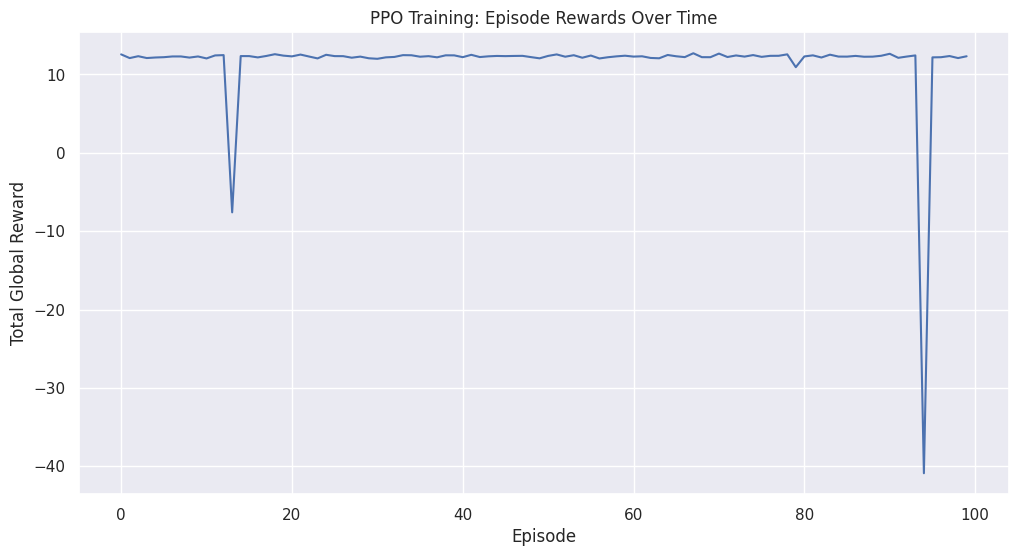


--- Visualizing Evaluation Scenario 1 ---


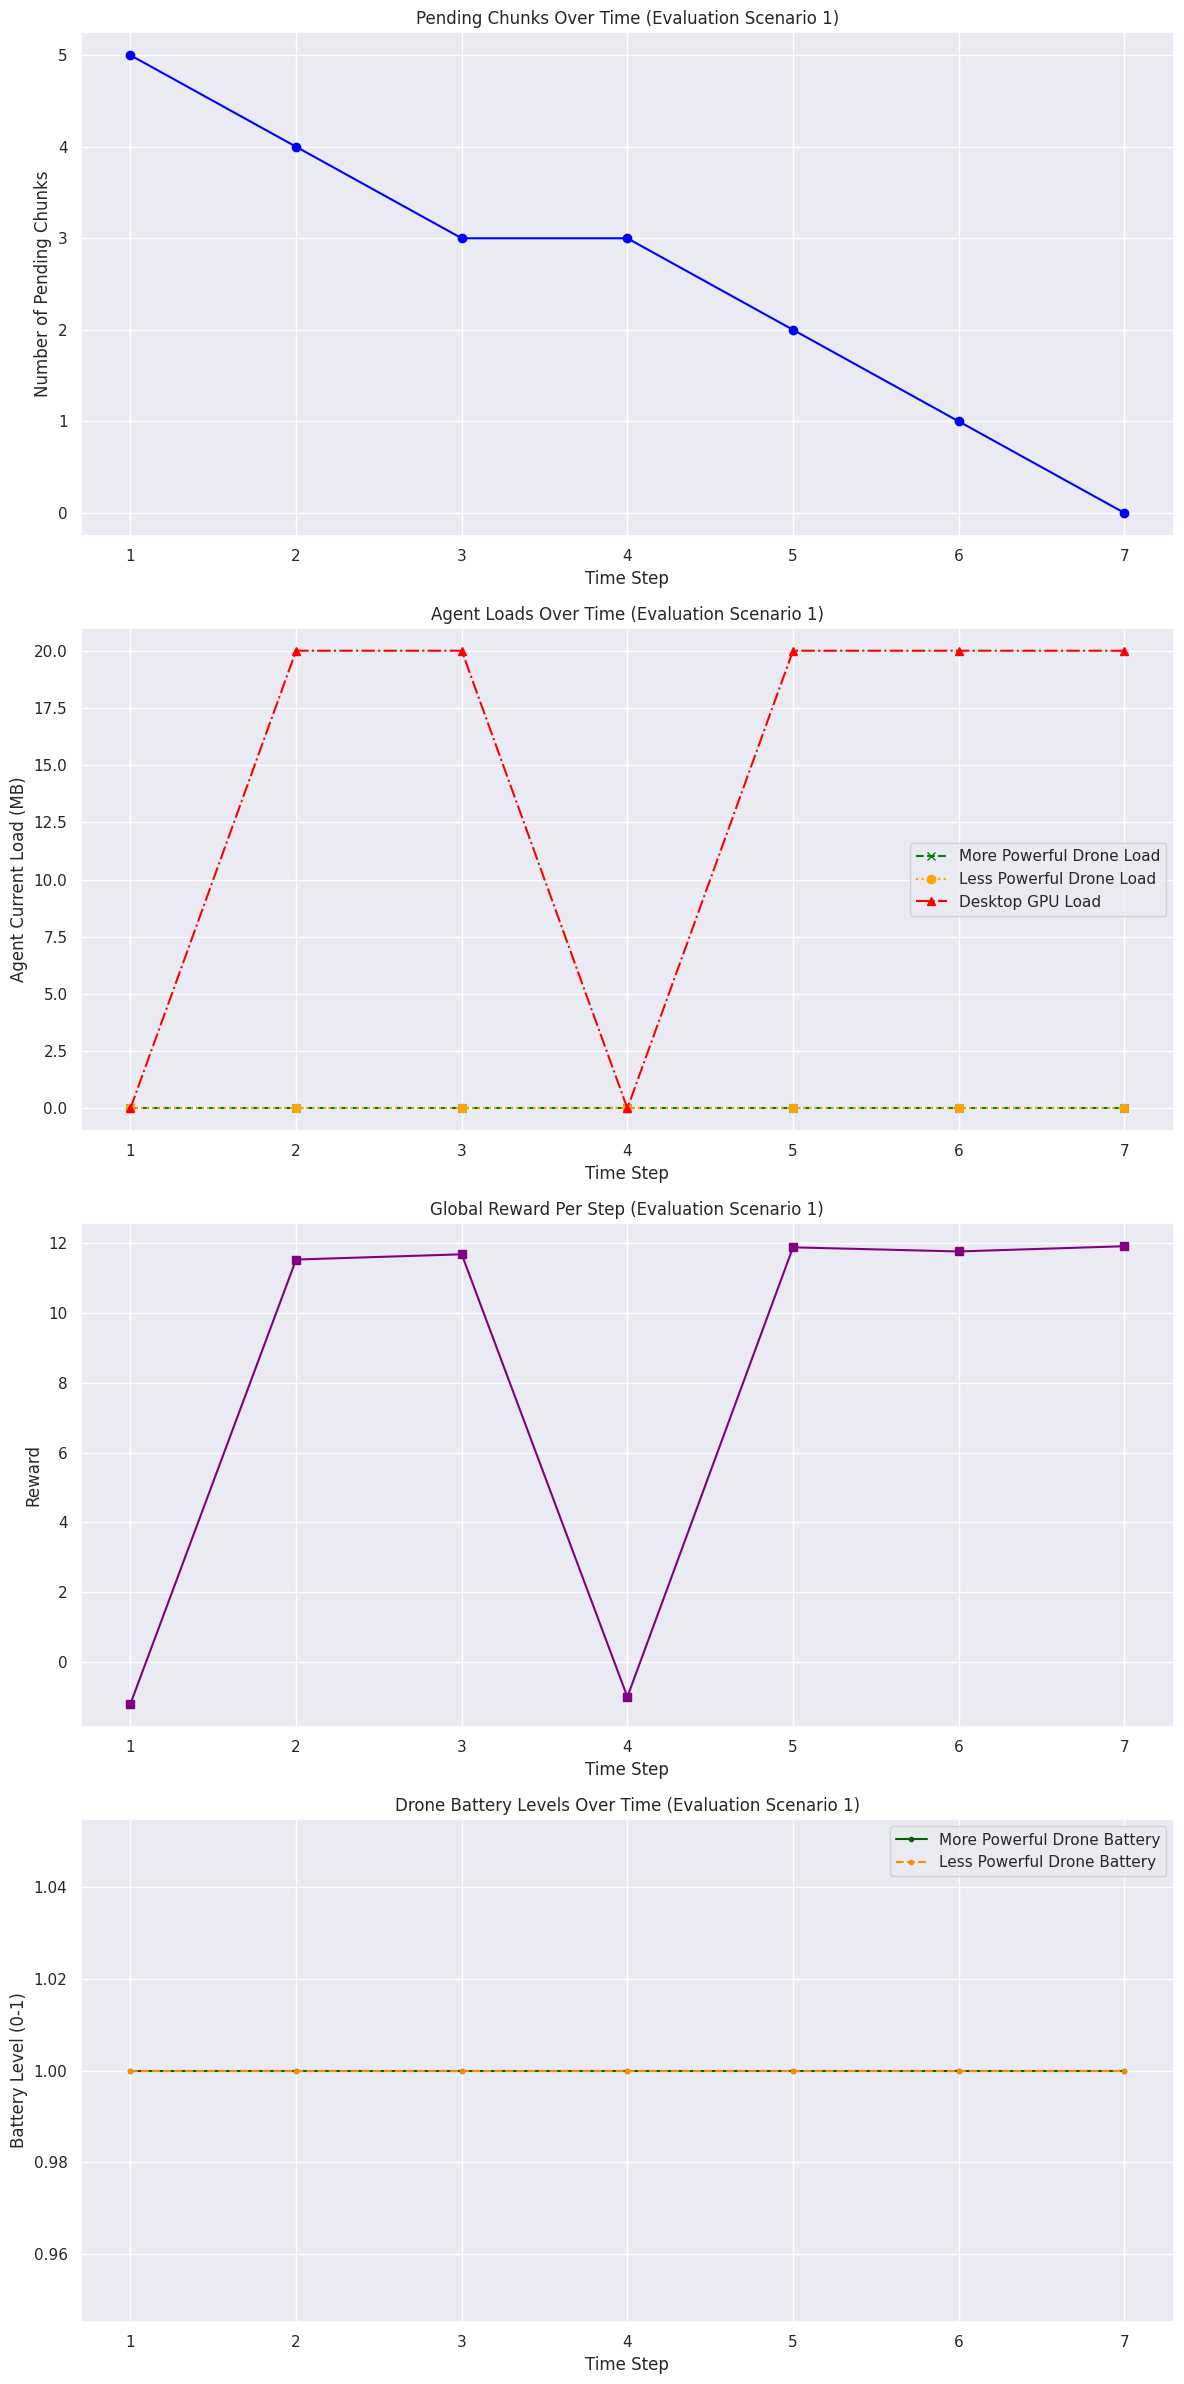

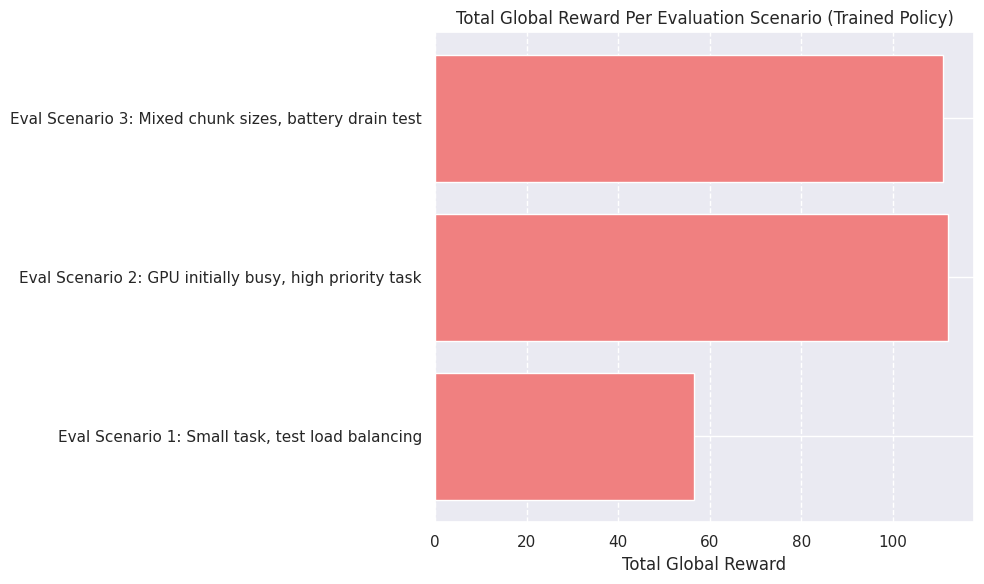

In [2]:
# --- 0. Install Required Libraries (Run first in Colab/Jupyter) ---
!pip install gymnasium stable-baselines3[extra] torch numpy matplotlib seaborn

# --- 1. Imports ---
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from gymnasium import spaces
import os
import traceback
import pickle

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback

sns.set_theme()

# --- 2. OffloadingEnv: Gymnasium Version (NO DEBUG PRINTS) ---
class OffloadingEnv(gym.Env):
    metadata = {'render_modes': ['human'], 'render_fps': 4}

    def __init__(self, initial_chunks_per_task=[5, 4], chunk_size_mb=20.0,
                 mpd_processing_speed=20.0, lpd_processing_speed=5.0,
                 gpu_processing_speed=40.0, gpu_busy_chance=0.3,
                 mpd_battery_drain_rate=0.01, lpd_battery_drain_rate=0.02,
                 network_latency_to_gpu=0.05, network_bandwidth_to_gpu=100.0,
                 network_latency_to_cloud=0.5, network_bandwidth_to_cloud=500.0,
                 base_task_deadline_steps=10, base_task_priority=0.5):
        try:
            super().__init__()
            self.agents = ["More Powerful Drone", "Less Powerful Drone", "Desktop GPU"]
            self.num_agents = len(self.agents)
            self.initial_chunks_per_task = initial_chunks_per_task
            self.chunk_size_mb = chunk_size_mb
            self.total_initial_chunks = sum(initial_chunks_per_task)
            self.agent_speeds = {
                "More Powerful Drone": mpd_processing_speed,
                "Less Powerful Drone": lpd_processing_speed,
                "Desktop GPU": gpu_processing_speed
            }
            self.agent_max_loads = {
                "More Powerful Drone": 20.0,
                "Less Powerful Drone": 10.0,
                "Desktop GPU": 40.0
            }
            self.mpd_battery_drain_rate = mpd_battery_drain_rate
            self.lpd_battery_drain_rate = lpd_battery_drain_rate
            self.network_latency_to_gpu = network_latency_to_gpu
            self.network_bandwidth_to_gpu = network_bandwidth_to_gpu
            self.network_latency_to_cloud = network_latency_to_cloud
            self.network_bandwidth_to_cloud = network_bandwidth_to_cloud
            self.base_task_deadline_steps = base_task_deadline_steps
            self.base_task_priority = base_task_priority
            self.gpu_busy_chance = gpu_busy_chance

            max_possible_tasks = len(initial_chunks_per_task) + 2
            max_possible_chunks = sum(initial_chunks_per_task) + 10
            max_chunk_size_plus_one = self.chunk_size_mb + 1
            max_task_id_idx = max(0, len(initial_chunks_per_task) - 1) if len(initial_chunks_per_task) > 0 else 0
            high_values = np.array([
                float(max_possible_tasks),
                float(max_possible_chunks),
                float(self.agent_max_loads["More Powerful Drone"]),
                float(self.agent_max_loads["Less Powerful Drone"]),
                float(self.agent_max_loads["Desktop GPU"]),
                1.0, float(max_chunk_size_plus_one), float(max_task_id_idx),
                1.0, 1.0, 1.0, 500.0, 1.0, 1000.0,
                float(self.base_task_deadline_steps * 2.0), 1.0
            ], dtype=np.float32)
            self.observation_space = spaces.Box(low=0, high=high_values, shape=(16,), dtype=np.float32)
            self.action_space = spaces.MultiDiscrete([2] * self.num_agents)
            self.reset()
        except Exception as e:
            print(f"Exception in OffloadingEnv.__init__: {e}")
            traceback.print_exc()
            raise

    def _initialize_tasks(self, chunks_per_task_list):
        tasks = {}
        for i, num_chunks in enumerate(chunks_per_task_list):
            task_id = f"Task {chr(65 + i)}"
            deadline = self.base_task_deadline_steps + random.randint(-5, 5)
            priority = max(0.0, min(1.0, self.base_task_priority + random.uniform(-0.2, 0.2)))
            chunks = deque([
                {
                    'size_mb': self.chunk_size_mb,
                    'task_id': task_id,
                    'initial_deadline': deadline,
                    'deadline_remaining': deadline,
                    'priority': priority
                } for _ in range(num_chunks)
            ])
            tasks[task_id] = chunks
        return tasks

    def _update_agent_states(self):
        for agent in self.agents:
            if self.agent_loads[agent] > 0:
                self.agent_loads[agent] = max(0, self.agent_loads[agent] - self.agent_speeds[agent])
        self.desktop_gpu_is_busy = (random.random() < self.gpu_busy_chance)
        if self.agent_loads["More Powerful Drone"] > 0:
            self.mpd_battery_level = max(0.0, self.mpd_battery_level - (self.mpd_battery_drain_rate * self.agent_speeds["More Powerful Drone"] / self.chunk_size_mb))
        if self.agent_loads["Less Powerful Drone"] > 0:
            self.lpd_battery_level = max(0.0, self.lpd_battery_level - (self.lpd_battery_drain_rate * self.agent_speeds["Less Powerful Drone"] / self.chunk_size_mb))
        for task_id in self.task_queues:
            for chunk in self.task_queues[task_id]:
                chunk['deadline_remaining'] -= 1

    def _get_obs(self):
        num_active_tasks = len([q for q in self.task_queues.values() if len(q) > 0])
        pending_chunks = sum(len(q) for q in self.task_queues.values())
        next_chunk_info = None
        for task_id in sorted(self.task_queues.keys()):
            if self.task_queues[task_id]:
                next_chunk_info = self.task_queues[task_id][0]
                break
        next_chunk_size = 0.0
        next_chunk_task_idx = 0
        next_chunk_deadline_remaining = 0.0
        next_chunk_priority = 0.0
        if next_chunk_info:
            next_chunk_size = next_chunk_info['size_mb']
            next_chunk_task_idx = (ord(next_chunk_info['task_id'][-1]) - ord('A'))
            next_chunk_deadline_remaining = next_chunk_info['deadline_remaining']
            next_chunk_priority = next_chunk_info['priority']
        observation = np.array([
            float(num_active_tasks),
            float(pending_chunks),
            float(self.agent_loads["More Powerful Drone"]),
            float(self.agent_loads["Less Powerful Drone"]),
            float(self.agent_loads["Desktop GPU"]),
            1.0 if self.desktop_gpu_is_busy else 0.0,
            float(next_chunk_size),
            float(next_chunk_task_idx),
            float(self.mpd_battery_level),
            float(self.lpd_battery_level),
            float(self.network_latency_to_gpu),
            float(self.network_bandwidth_to_gpu),
            float(self.network_latency_to_cloud),
            float(self.network_bandwidth_to_cloud),
            float(next_chunk_deadline_remaining),
            float(next_chunk_priority)
        ], dtype=np.float32)
        return observation

    def step(self, joint_actions):
        try:
            self.time_step += 1
            self._update_agent_states()
            global_reward = 0
            processed_this_step = False
            outcome_log = {}
            actions_dict = {self.agents[i]: joint_actions[i] for i in range(self.num_agents)}
            current_chunk = None
            current_task_id = None
            for task_id in sorted(self.task_queues.keys()):
                if self.task_queues[task_id]:
                    current_chunk = self.task_queues[task_id][0]
                    current_task_id = task_id
                    break
            if current_chunk:
                chosen_agent_for_chunk = None
                for agent_name in self.agents:
                    action_idx = int(actions_dict.get(agent_name))
                    can_process = True
                    if action_idx == 1:
                        if self.agent_loads[agent_name] > 0:
                            can_process = False
                        elif agent_name == "Less Powerful Drone" and current_chunk['size_mb'] > self.agent_max_loads["Less Powerful Drone"]:
                            can_process = False
                        elif agent_name == "Desktop GPU" and self.desktop_gpu_is_busy:
                            can_process = False
                        if can_process:
                            chosen_agent_for_chunk = agent_name
                            break
                for agent_name in self.agents:
                    action_str = "PROCESS_CHUNK" if actions_dict[agent_name] == 1 else "IGNORE"
                    outcome_log[agent_name] = action_str
                if chosen_agent_for_chunk:
                    chunk_processed = self.task_queues[current_task_id].popleft()
                    self.agent_loads[chosen_agent_for_chunk] += chunk_processed['size_mb']
                    self.processed_chunks_count += 1
                    global_reward += 10
                    processed_this_step = True
                    outcome_log["OUTCOME"] = f"Processed by {chosen_agent_for_chunk}"
                    if chosen_agent_for_chunk == "Less Powerful Drone":
                        global_reward += 2
                    elif chosen_agent_for_chunk == "More Powerful Drone":
                        global_reward -= 0.1
                    elif chosen_agent_for_chunk == "Desktop GPU":
                        global_reward += 1
                    global_reward += current_chunk['priority'] * 1.0
                    global_reward += (max(0, current_chunk['initial_deadline'] - current_chunk['deadline_remaining'])) * 0.05
                else:
                    outcome_log["OUTCOME"] = "No capable or willing agent processed chunk"
                    global_reward -= 0.5
            else:
                outcome_log["OUTCOME"] = "No chunks left to process"
            global_reward -= sum(len(q) for q in self.task_queues.values()) * 0.1
            if not processed_this_step and sum(len(q) for q in self.task_queues.values()) > 0:
                total_available_capacity = 0
                for agent_name in self.agents:
                    if self.agent_loads[agent_name] == 0:
                        if agent_name == "Desktop GPU" and self.desktop_gpu_is_busy:
                            continue
                        total_available_capacity += self.agent_max_loads[agent_name]
                if total_available_capacity > 0 and current_chunk:
                    can_any_process = False
                    for agent_name in self.agents:
                        if self.agent_loads[agent_name] == 0:
                            if not (agent_name == "Less Powerful Drone" and current_chunk['size_mb'] > self.agent_max_loads["Less Powerful Drone"]) and \
                               not (agent_name == "Desktop GPU" and self.desktop_gpu_is_busy):
                                can_any_process = True
                                break
                    if can_any_process:
                        global_reward -= 0.2
            global_reward -= (1.0 - self.mpd_battery_level) * 0.5
            global_reward -= (1.0 - self.lpd_battery_level) * 0.7
            if self.mpd_battery_level <= 0.05: global_reward -= 5.0
            if self.lpd_battery_level <= 0.05: global_reward -= 7.0
            missed_deadline_count = 0
            for task_id in self.task_queues:
                for chunk in list(self.task_queues[task_id]):
                    if chunk['deadline_remaining'] <= 0:
                        global_reward -= 20.0
                        missed_deadline_count += 1
            global_reward -= (self.agent_loads["More Powerful Drone"] / self.agent_max_loads["More Powerful Drone"]) * 0.05
            global_reward -= (self.agent_loads["Less Powerful Drone"] / self.agent_max_loads["Less Powerful Drone"]) * 0.1
            global_reward -= (self.agent_loads["Desktop GPU"] / self.agent_max_loads["Desktop GPU"]) * 0.02
            terminated = self.processed_chunks_count == self.total_initial_chunks or missed_deadline_count > 0
            truncated = self.time_step >= self.max_steps
            observation = self._get_obs()
            info = {"processed_this_step": processed_this_step, "outcome_log": outcome_log,
                    "current_agent_loads": self.agent_loads.copy(),
                    "mpd_battery": self.mpd_battery_level, "lpd_battery": self.lpd_battery_level,
                    "gpu_busy": self.desktop_gpu_is_busy,
                    "missed_deadline_count": missed_deadline_count}
            self.history.append({"time_step": self.time_step, "state_obs": observation.copy(),
                                 "agent_loads": self.agent_loads.copy(),
                                 "actions": actions_dict, "reward": global_reward,
                                 "terminated": terminated, "truncated": truncated,
                                 "outcome": outcome_log.get("OUTCOME", "N/A")})
            return observation, global_reward, terminated, truncated, info
        except Exception as e:
            print(f"Exception in OffloadingEnv.step: {e}")
            traceback.print_exc()
            raise

    def reset(self, *, seed=None, options=None):
        try:
            super().reset(seed=seed)
            # Accept scenario-specific initial chunks via options dict
            if options is not None and "initial_chunks_per_task" in options:
                self.initial_chunks_per_task = options["initial_chunks_per_task"]
            self.time_step = 0
            self.processed_chunks_count = 0
            self.agent_loads = {agent: 0 for agent in self.agents}
            self.desktop_gpu_is_busy = False
            self.mpd_battery_level = 1.0
            self.lpd_battery_level = 1.0
            self.task_queues = self._initialize_tasks(self.initial_chunks_per_task)
            self.total_initial_chunks = sum(self.initial_chunks_per_task)
            self.history = []
            self.max_steps = 100
            observation = self._get_obs()
            info = {}
            return observation, info
        except Exception as e:
            print(f"Exception in OffloadingEnv.reset: {e}")
            traceback.print_exc()
            raise

    def render(self):
        pass
    def close(self):
        pass

# --- 3. Custom Callback for SB3 ---
class CustomCallback(BaseCallback):
    def __init__(self, verbose: int = 0):
        super().__init__(verbose)
        self.rewards = []
        self.num_episodes = 0
        self.episode_rewards = deque(maxlen=100)
    def _on_step(self) -> bool:
        for i, done in enumerate(self.locals["dones"]):
            if done:
                self.episode_rewards.append(self.locals["rewards"][i])
                self.num_episodes += 1
                if self.num_episodes % 10 == 0:
                    print(f"Episode: {self.num_episodes}, Last {len(self.episode_rewards)} Avg Reward: {np.mean(self.episode_rewards):.2f}")
        return True
    def _on_training_end(self) -> None:
        print(f"Training ended. Total episodes: {self.num_episodes}")
        if len(self.episode_rewards) > 0:
            print(f"Average reward over recorded episodes: {np.mean(self.episode_rewards):.2f}")
        else:
            print("No episodes completed during training (or rewards not recorded).")

# --- 4. Environment Setup and SB3 VecEnv Test ---
env_params = {
    "mpd_processing_speed": 20.0,
    "lpd_processing_speed": 5.0,
    "gpu_processing_speed": 40.0,
    "gpu_busy_chance": 0.3,
    "mpd_battery_drain_rate": 0.005,
    "lpd_battery_drain_rate": 0.01,
    "network_latency_to_gpu": 0.05,
    "network_bandwidth_to_gpu": 100.0,
    "network_latency_to_cloud": 0.5,
    "network_bandwidth_to_cloud": 500.0,
    "base_task_deadline_steps": 20,
    "base_task_priority": 0.7
}
n_envs = 4

print("Testing env with DummyVecEnv for debugging...")
try:
    dummy_vec_env = make_vec_env(OffloadingEnv, n_envs=1, env_kwargs=env_params, vec_env_cls=DummyVecEnv)
    obs = dummy_vec_env.reset()  # SB3 VecEnv returns only obs
    print("DummyVecEnv reset successful.")
except Exception as e:
    print("DummyVecEnv test failed. See above for error.")
    raise

print("Testing picklability of OffloadingEnv...")
try:
    env = OffloadingEnv(**env_params)
    pickle.dumps(env)
    print("OffloadingEnv is picklable!")
except Exception as e:
    print("OffloadingEnv is NOT picklable! See above for error.")
    raise

print("Using DummyVecEnv for all training and evaluation (not parallel, but works in notebooks).")
vec_env = make_vec_env(
    OffloadingEnv,
    n_envs=n_envs,
    env_kwargs=env_params,
    vec_env_cls=DummyVecEnv
)

# --- 5. Training ---
log_dir = "ppo_offloading_logs"
os.makedirs(log_dir, exist_ok=True)
model = PPO("MlpPolicy", vec_env, verbose=1, learning_rate=0.0003,
            n_steps=2048, batch_size=64, gamma=0.99,
            tensorboard_log=log_dir)
total_timesteps = 500000
print(f"\n--- Starting PPO Training for {total_timesteps} timesteps ---")
custom_callback = CustomCallback(verbose=1)
model.learn(total_timesteps=total_timesteps, callback=custom_callback)
print("--- PPO Training Complete ---")
model_save_path = "ppo_offloading_policy"
model.save(model_save_path)
print(f"Trained model saved to {model_save_path}.zip")

# --- 6. Evaluation of the Trained Policy ---
print("\n--- Evaluating Trained Policy ---")
eval_env = OffloadingEnv(initial_chunks_per_task=[5, 4], chunk_size_mb=20.0, **env_params)

def run_trained_scenario(env, model, scenario_name, initial_chunks, max_steps=100):
    print(f"\n============================================================")
    print(f"--- EVALUATION SCENARIO: {scenario_name} ---")
    print(f"============================================================")
    env.max_steps = max_steps
    obs, _ = env.reset(options={"initial_chunks_per_task": initial_chunks})
    print(f"  > Initial State: {obs[1]:.0f} chunks to process across {obs[0]:.0f} task queues.")
    terminated = False
    truncated = False
    step_count = 0
    total_reward = 0
    while not terminated and not truncated:
        step_count += 1
        joint_actions_np, _states = model.predict(obs, deterministic=True)
        actions_dict_for_log = {env.agents[i]: int(joint_actions_np[i]) for i in range(env.num_agents)}
        next_chunk_size = obs[6]
        next_chunk_task_id_idx = int(obs[7])
        task_char = chr(65 + next_chunk_task_id_idx) if next_chunk_task_id_idx >= 0 else 'N/A'
        print(f"\n    Step {step_count} (Next Chunk Size: {next_chunk_size}MB, Task: {task_char}):")
        for i, agent_name in enumerate(env.agents):
            action_str = "PROCESS_CHUNK" if joint_actions_np[i] == 1 else "IGNORE"
            print(f"      - {agent_name} decision: {action_str}")
        obs, reward, terminated, truncated, info = env.step(joint_actions_np)
        total_reward += reward
        print(f"      ==> OUTCOME: {info['outcome_log'].get('OUTCOME', 'N/A')}")
    if terminated:
        print(f"\n  --- SCENARIO {scenario_name} COMPLETE ---")
        print(f"  Total Chunks Processed: {env.processed_chunks_count}")
        print(f"  Total Steps: {env.time_step}")
        print(f"  Total Global Reward: {total_reward:.2f}")
    elif truncated:
        print(f"\n  --- SCENARIO {scenario_name} Halted (Max Steps Reached) ---")
        print(f"  Chunks Remaining: {obs[1]:.0f}")
        print(f"  Total Chunks Processed: {env.processed_chunks_count}")
        print(f"  Total Steps: {env.time_step}")
        print(f"  Total Global Reward: {total_reward:.2f}")
    return env.history, total_reward

eval_scenarios = [
    {"name": "Eval Scenario 1: Small task, test load balancing", "chunks": [3, 2]},
    {"name": "Eval Scenario 2: GPU initially busy, high priority task", "chunks": [10]},
    {"name": "Eval Scenario 3: Mixed chunk sizes, battery drain test", "chunks": [6, 4]},
]
eval_results = {}
for scenario_params in eval_scenarios:
    history, final_reward = run_trained_scenario(
        eval_env,
        model,
        scenario_params["name"],
        scenario_params["chunks"],
        max_steps=50
    )
    eval_results[scenario_params["name"]] = {"history": history, "final_reward": final_reward}
print("\n--- Evaluation Complete ---")

# --- 7. Visualization ---
if custom_callback.episode_rewards:
    plt.figure(figsize=(12, 6))
    plt.plot(np.arange(len(custom_callback.episode_rewards)), list(custom_callback.episode_rewards))
    plt.title('PPO Training: Episode Rewards Over Time')
    plt.xlabel('Episode')
    plt.ylabel('Total Global Reward')
    plt.grid(True)
    plt.show()

print("\n--- Visualizing Evaluation Scenario 1 ---")
if eval_scenarios and eval_scenarios[0]["name"] in eval_results and eval_results[eval_scenarios[0]["name"]]["history"]:
    eval_scenario1_history = eval_results[eval_scenarios[0]["name"]]["history"]
    time_steps = [entry['time_step'] for entry in eval_scenario1_history]
    pending_chunks = [entry['state_obs'][1] for entry in eval_scenario1_history]
    mpd_loads = [entry['agent_loads']["More Powerful Drone"] for entry in eval_scenario1_history]
    lpd_loads = [entry['agent_loads']["Less Powerful Drone"] for entry in eval_scenario1_history]
    gpu_loads = [entry['agent_loads']["Desktop GPU"] for entry in eval_scenario1_history]
    rewards = [entry['reward'] for entry in eval_scenario1_history]
    mpd_battery = [entry['state_obs'][8] for entry in eval_scenario1_history]
    lpd_battery = [entry['state_obs'][9] for entry in eval_scenario1_history]
    fig, axes = plt.subplots(4, 1, figsize=(12, 24))
    axes[0].plot(time_steps, pending_chunks, marker='o', linestyle='-', color='blue')
    axes[0].set_title('Pending Chunks Over Time (Evaluation Scenario 1)')
    axes[0].set_xlabel('Time Step')
    axes[0].set_ylabel('Number of Pending Chunks')
    axes[0].grid(True)
    axes[1].plot(time_steps, mpd_loads, label='More Powerful Drone Load', marker='x', linestyle='--', color='green')
    axes[1].plot(time_steps, lpd_loads, label='Less Powerful Drone Load', marker='o', linestyle=':', color='orange')
    axes[1].plot(time_steps, gpu_loads, label='Desktop GPU Load', marker='^', linestyle='-.', color='red')
    axes[1].set_title('Agent Loads Over Time (Evaluation Scenario 1)')
    axes[1].set_xlabel('Time Step')
    axes[1].set_ylabel('Agent Current Load (MB)')
    axes[1].legend()
    axes[1].grid(True)
    axes[2].plot(time_steps, rewards, marker='s', linestyle='-', color='purple')
    axes[2].set_title('Global Reward Per Step (Evaluation Scenario 1)')
    axes[2].set_xlabel('Time Step')
    axes[2].set_ylabel('Reward')
    axes[2].grid(True)
    axes[3].plot(time_steps, mpd_battery, label='More Powerful Drone Battery', marker='.', linestyle='-', color='darkgreen')
    axes[3].plot(time_steps, lpd_battery, label='Less Powerful Drone Battery', marker='.', linestyle='--', color='darkorange')
    axes[3].set_title('Drone Battery Levels Over Time (Evaluation Scenario 1)')
    axes[3].set_xlabel('Time Step')
    axes[3].set_ylabel('Battery Level (0-1)')
    axes[3].legend()
    axes[3].grid(True)
    plt.tight_layout()
    plt.show()
else:
     print("Evaluation Scenario 1 history is not available for plotting.")

eval_scenario_names = [s["name"] for s in eval_scenarios]
if all(name in eval_results for name in eval_scenario_names):
    eval_final_rewards = [eval_results[name]["final_reward"] for name in eval_scenario_names]
    plt.figure(figsize=(10, 6))
    plt.barh(eval_scenario_names, eval_final_rewards, color='lightcoral')
    plt.xlabel('Total Global Reward')
    plt.title('Total Global Reward Per Evaluation Scenario (Trained Policy)')
    plt.grid(axis='x', linestyle='--')
    plt.tight_layout()
    plt.show()
else:
    print("Evaluation results are incomplete for plotting scenario comparison.")